In [2]:
import numpy as np
from psdebias import multitaper,lag_window,welch,periodogram, fit_psd, ar_spectrum, sample_ar
import matplotlib.pyplot as plt

In [1]:
def print_mse_bias_var(est, truth):
    le, lt = np.log(est), np.log(truth)
    MSE = np.mean((le - lt)**2)
    Bias = np.mean(le - lt)
    Var = MSE - Bias**2
    print(f"MSE: {MSE:.2f}, Bias: {Bias:.2f}, Var: {Var:.2f}")

# Demo

32.0


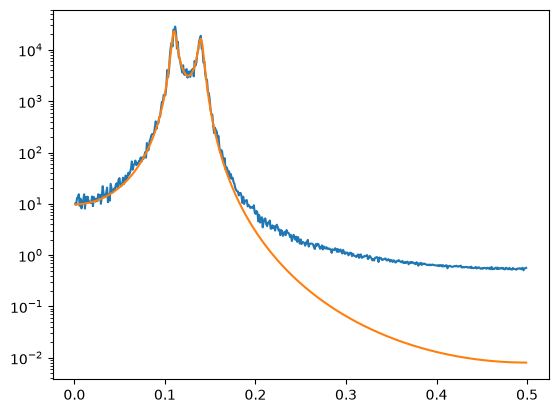

In [29]:
# --- simulate the paper's AR(4) process -------------------------------------
ar_poly = np.array([1.0, -2.7607, 3.8106, -2.6535, 0.9238])  # [1, -phi...]

n = 2**15
x = sample_ar(1, n, ar_poly, rng=np.random.default_rng(0))[0]

# --- any quadratic estimator; note the third output: the bias kernel --------
L = 1024
M = n//L
est = welch(x,segment_length=L, n_segments =M, step=L,taper=np.ones(L))
# est = lag_window(x,window="bartlett",lag=n//15)
print(est.dof)
# est = multitaper(x,nw=4)
true_spectrum = ar_spectrum(est.freqs,ar_poly, sd=1.0)

plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs, true_spectrum)

## Fit

In [30]:
number_of_knots = 128 
knot_spacing = int(np.ceil(len(est.freqs))/number_of_knots)

In [31]:
# --- the full PSDebias workflow in one call ---------------------------------
fit = fit_psd(
    est, # Estimate in SpectralEstimate class
    n_time=L,   # the estimator's window, for the diagnostic/debias
    mode="debias",                  # sign diagnostic picks "debias" or "smooth"
    knot_spacing=knot_spacing,               # one candidate knot per 4 frequency bins
    rng=np.random.default_rng(),
    n_iterations=50_000, warmup=20_000,
)

In [32]:
fit.mean          # posterior-mean PSD (always linear scale)
fit.std           # pointwise posterior std
print(fit.mode)          # which regime the diagnostic chose
fit.expected_knots, fit.acceptance_rate

debias


(18.7572, 0.2713285714285714)

In [33]:
est.dof

np.float64(32.0)

PSD
MSE: 6.56, Bias: 1.95, Var: 2.76
PSDebias
MSE: 2.51, Bias: 1.06, Var: 1.40


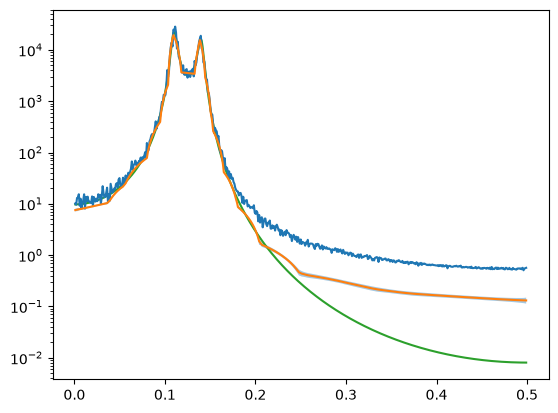

In [34]:
plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs, fit.mean)
plt.fill_between(est.freqs, fit.mean - fit.std, fit.mean + fit.std,alpha=0.4)
plt.semilogy(est.freqs, true_spectrum,zorder=1)
print("PSD")
print_mse_bias_var(est.psd, true_spectrum)
print("PSDebias")
print_mse_bias_var(fit.mean, true_spectrum)

## dwelch

In [35]:
from psdebias import dwelch_b0
gamma = np.zeros(len(est.freqs), dtype=np.int8)
gamma[::32] = 1                                   # a uniform mesh
_, debiased = dwelch_b0(est.psd, est.freqs, gamma=gamma, kernel=est.kernel, n_time=L)

PSD
MSE: 6.56, Bias: 1.95, Var: 2.76
PSDebias
MSE: 2.51, Bias: 1.06, Var: 1.40
DQuad
MSE: 6.53, Bias: 1.56, Var: 4.08


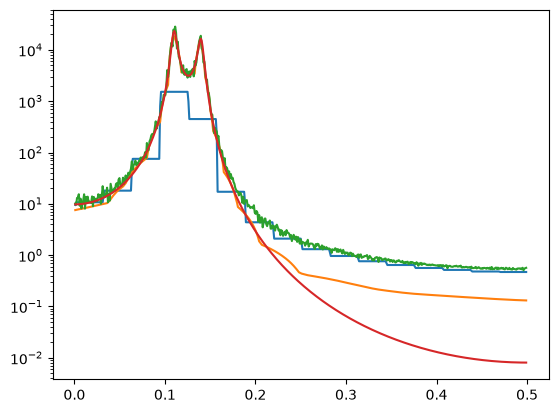

In [37]:
plt.semilogy(est.freqs, debiased)
plt.semilogy(est.freqs,fit.mean)
plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs,true_spectrum)

print("PSD")
print_mse_bias_var(est.psd, true_spectrum)
print("PSDebias")
print_mse_bias_var(fit.mean, true_spectrum)
print("DQuad")
print_mse_bias_var(debiased, true_spectrum)

# Sunspot

In [3]:
x = np.genfromtxt("../data/SN_y_tot_V2.0.csv",delimiter=';').T[1]
x -= np.mean(x)

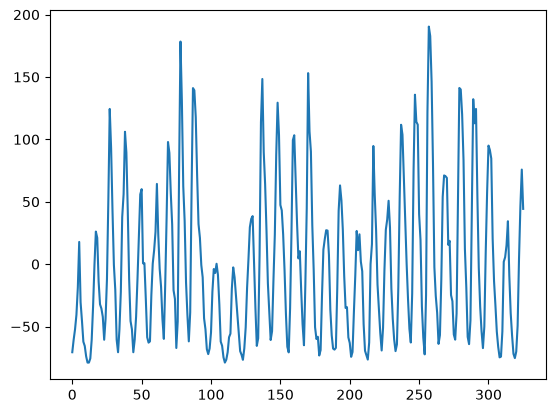

In [4]:
plt.plot(x)

In [39]:
M = 3
N = len(x)
p = 0.5
L = int(N // (M * (1-p) + p))
step = int((1-p) * L)

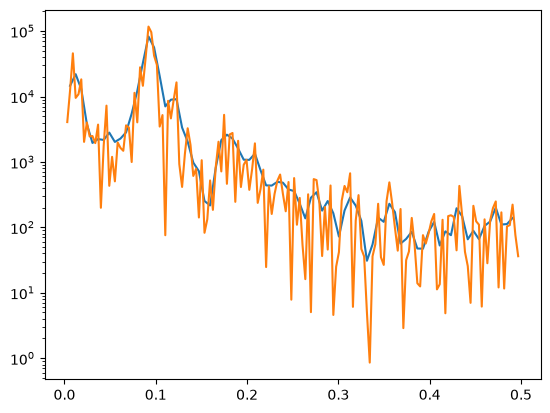

In [40]:
est = welch(x,segment_length=L,n_segments=M,step=step,taper=np.hamming(L))
# est = multitaper(x,nw=5)
# est = lag_window(x,window='bartlett',lag=len(x)//6)
per = periodogram(x)
plt.semilogy(est.freqs, est.psd)
plt.semilogy(per.freqs, per.psd)

In [41]:
# --- the full PSDebias workflow in one call ---------------------------------
fit = fit_psd(
    est,
    n_time=L,   # the estimator's window, for the diagnostic/debias
    mode="auto",                  # sign diagnostic picks "debias" or "smooth"
    knot_spacing=1,               # one candidate knot per 1 frequency bins
    rng=np.random.default_rng(1),
    n_iterations=50_000, warmup=20_000,
)

In [42]:
est.dof

np.float64(2.794268326169505)

In [43]:
fit.expected_knots

23.879

MSE: 0.12, Bias: -0.15, Var: 0.09


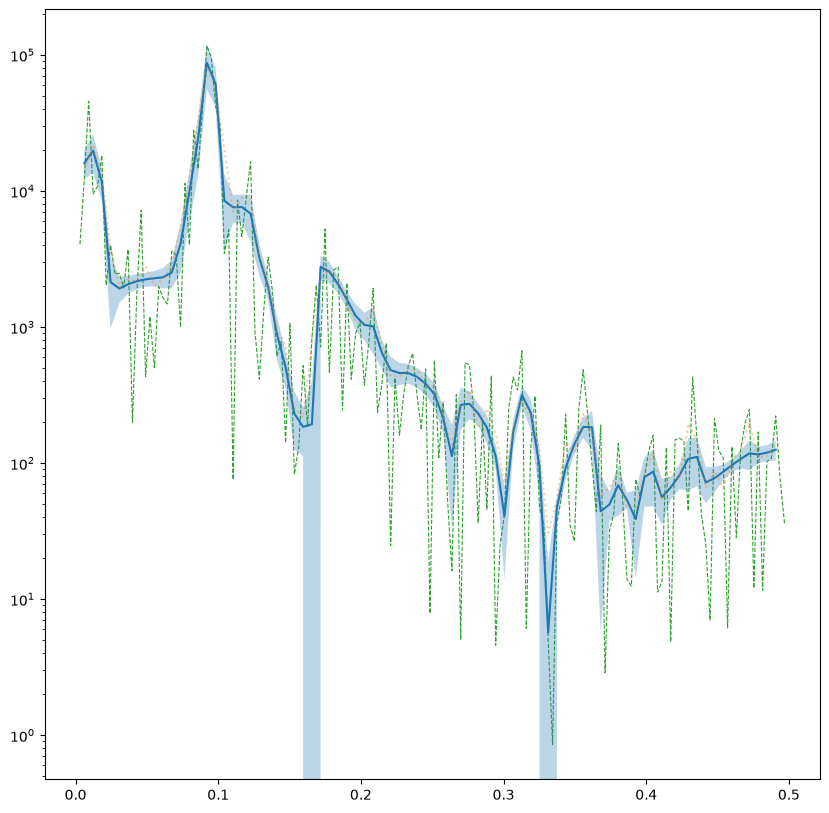

In [44]:
plt.figure(figsize=(10,10))

plt.semilogy(est.freqs, fit.mean)
plt.semilogy(est.freqs, est.psd,alpha=0.4,linestyle='dotted')
plt.semilogy(per.freqs, per.psd,lw=0.8,linestyle='dashed',zorder=1)

plt.fill_between(est.freqs, fit.mean - fit.std, fit.mean + fit.std,alpha=0.3)
print_mse_bias_var(fit.mean, est.psd)